In [6]:
import os
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import pyarrow.dataset as ds
import pyarrow.fs as fs
import seaborn as sns
from pathlib import Path

### Generate plots

In [7]:
crps_all_sites = pd.read_csv("crps_all_sites_tgxgb.csv")
plot_df = (
    crps_all_sites
    .groupby(["model_id", "horizon"], as_index=False)["crps"]
    .mean()
)

site_summary = (
    crps_all_sites
    .groupby(["site_id", "model_id"], as_index=False)["crps"]
    .mean()
)

site_summary.to_csv("/home/xinyiw/site_summary_crps_tgXGB.csv", index=False)

### show by reference_time

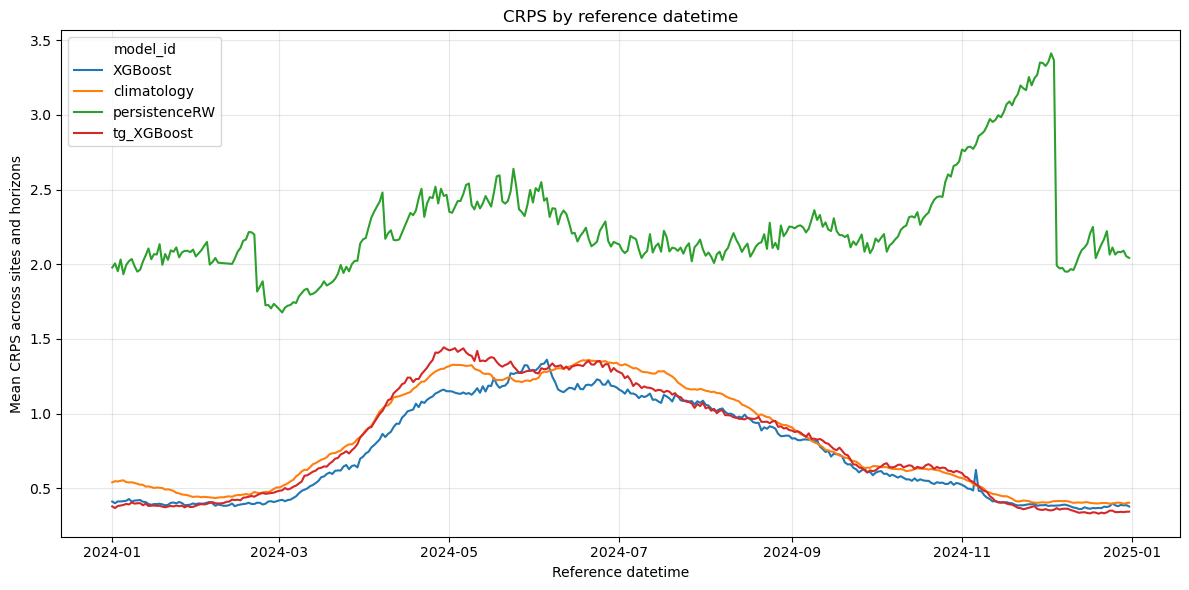

In [8]:


crps_all_sites["reference_datetime"] = pd.to_datetime(crps_all_sites["reference_datetime"])
crps_all_sites["datetime"] = pd.to_datetime(crps_all_sites["datetime"])

plot_ref = (
    crps_all_sites
    .groupby(["model_id", "reference_datetime"], as_index=False)["crps"]
    .mean()
)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=plot_ref,
    x="reference_datetime",
    y="crps",
    hue="model_id",
    # marker="o",
    linewidth=1.5
)

plt.xlabel("Reference datetime")
plt.ylabel("Mean CRPS across sites and horizons")
plt.title("CRPS by reference datetime")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

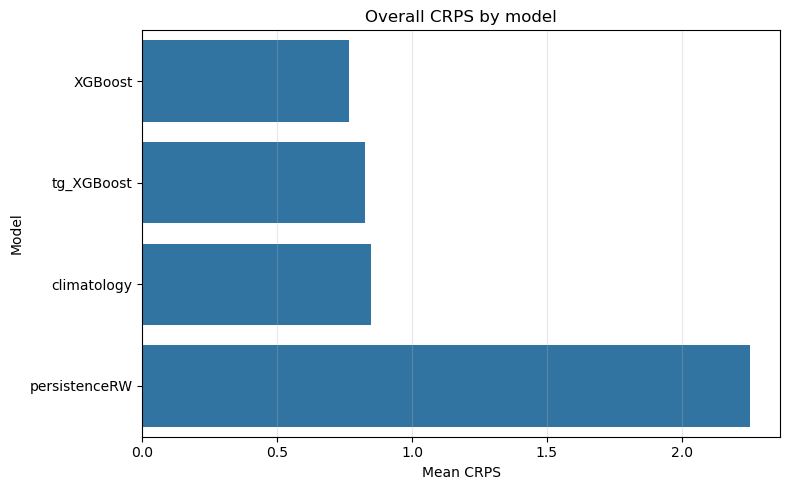

In [9]:
plot_model = (
    crps_all_sites
    .groupby("model_id", as_index=False)["crps"]
    .mean()
    .sort_values("crps")
)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=plot_model,
    x="crps",
    y="model_id"
)

plt.xlabel("Mean CRPS")
plt.ylabel("Model")
plt.title("Overall CRPS by model")
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

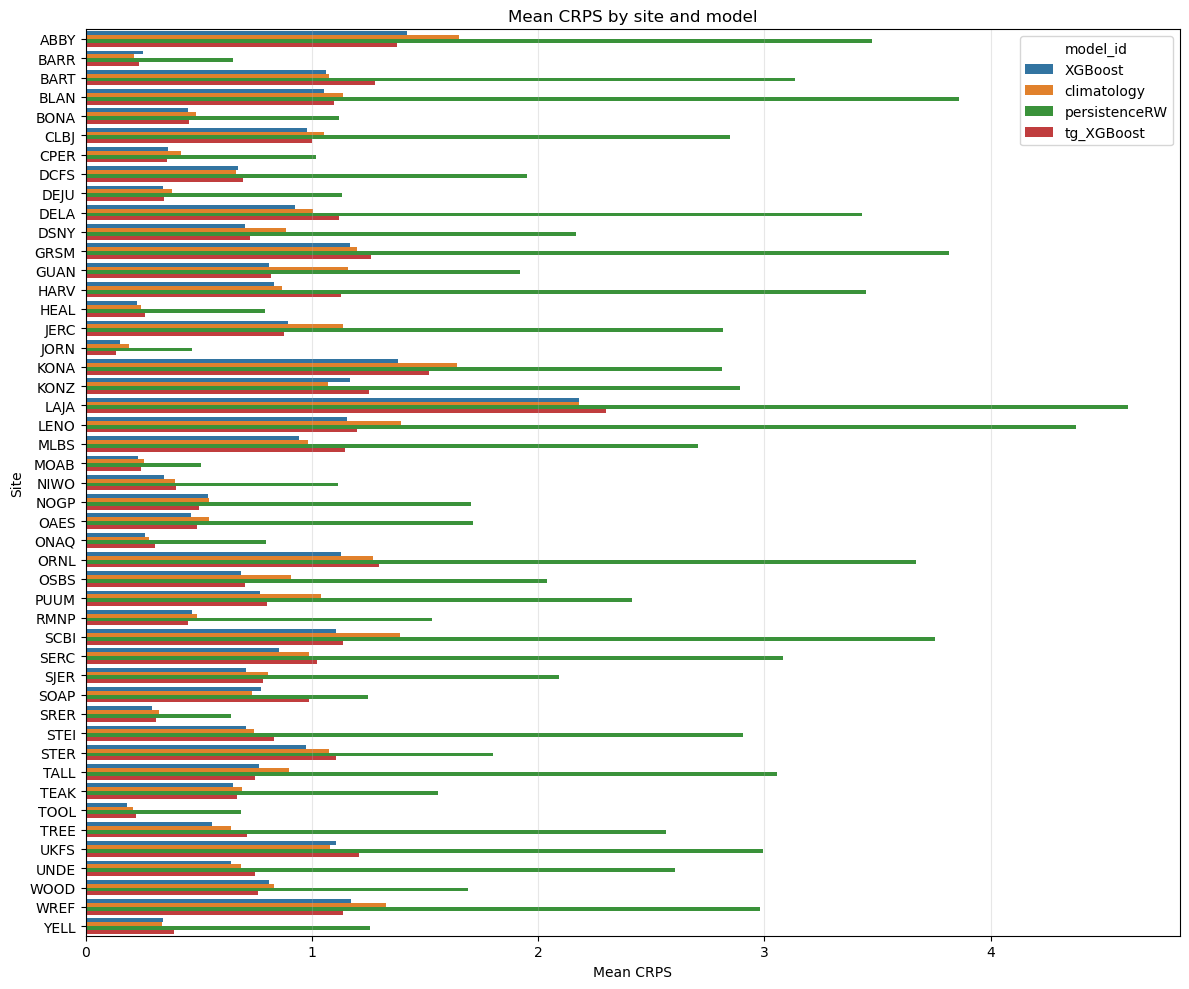

In [10]:
plot_site = (
    crps_all_sites
    .groupby(["site_id", "model_id"], as_index=False)["crps"]
    .mean()
)

plt.figure(figsize=(12, 10))
sns.barplot(
    data=plot_site,
    x="crps",
    y="site_id",
    hue="model_id"
)

plt.xlabel("Mean CRPS")
plt.ylabel("Site")
plt.title("Mean CRPS by site and model")
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()